
=== Format Compliance ===
                      model  total  strict  strict_pct  lenient  lenient_pct
0           aya-expanse-32b    119       0         0.0      118        99.16
1                gemma3-12b    120       0         0.0      120       100.00
2                gemma3-27b    120       0         0.0      120       100.00
3                     gpt4o    120       0         0.0      120       100.00
4                  llama3.1    120       0         0.0      120       100.00
5           llama3.2-latest    120       0         0.0      120       100.00
6           llama3.3-latest    120       0         0.0      120       100.00
7     mistral-small-3.2-24b    120       0         0.0      120       100.00
8   mistral-small3.1-latest    120       0         0.0      120       100.00
9               qwen2.5-14b    120       0         0.0      120       100.00
10              qwen2.5-32b    120       0         0.0      120       100.00
11              qwen2.5-72b    120       0       

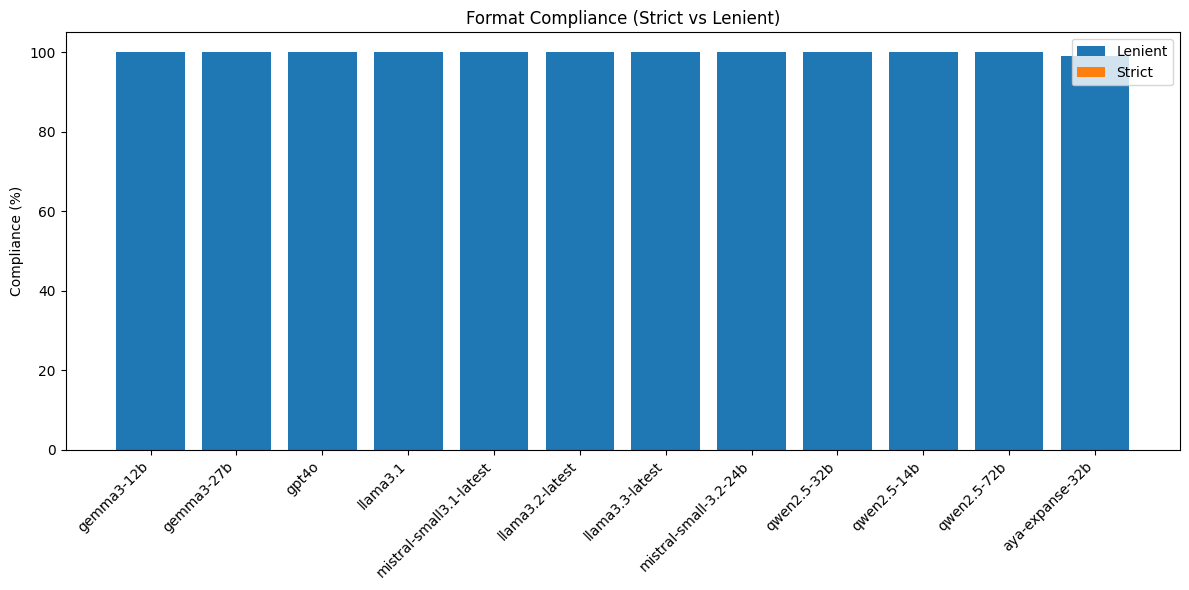

In [5]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

data_path = "./"
csv_files = [
    "aya-expanse-32b_test.csv",
    "gemma3-12b_test.csv",
    "gemma3-27b_test.csv",
    "gpt4o_test.csv",
    "llama3.1_test.csv",
    "llama3.2-latest_test.csv",
    "llama3.3-latest_test.csv",
    "mistral-small-3.2-24b_test.csv",
    "mistral-small3.1-latest_test.csv",
    "qwen2.5-14b_test.csv",
    "qwen2.5-32b_test.csv",
    "qwen2.5-72b_test.csv",
]

def strip_think_blocks(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()

# Strict: exactly 2 lines with "Answer: X" + "Reason: ..."
STRICT_PATTERN = re.compile(
    r"^\s*Answer:\s*([ABC])\s*\r?\nReason:\s*(.+)$",
    flags=re.IGNORECASE
)

# Lenient: accepts "Answer: X - ..." or just "X - ..." on one line
LENIENT_PATTERN = re.compile(
    r"^\s*(Answer:\s*)?([ABC])\s*[-:\)]\s*.+",
    flags=re.IGNORECASE
)

rows = []
for file in csv_files:
    path = os.path.join(data_path, file)
    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)
    model = file.replace("_test.csv", "")
    if "answer" not in df.columns:
        continue

    tmp = df[["scenario_code", "answer"]].copy()
    tmp["model"] = model
    tmp["answer"] = tmp["answer"].astype(str).fillna("")
    tmp["clean"] = tmp["answer"].apply(strip_think_blocks)

    tmp["strict_ok"] = tmp["clean"].apply(lambda s: STRICT_PATTERN.match(s) is not None)
    tmp["lenient_ok"] = tmp["clean"].apply(lambda s: LENIENT_PATTERN.match(s) is not None)

    tmp = tmp.drop_duplicates(subset=["scenario_code", "model"], keep="last")
    rows.append(tmp)

all_df = pd.concat(rows, ignore_index=True)

summary = (
    all_df.groupby("model")[["strict_ok","lenient_ok"]]
    .agg(total=("strict_ok","count"), strict=("strict_ok","sum"), lenient=("lenient_ok","sum"))
    .reset_index()
)
summary["strict_pct"] = (summary["strict"] / summary["total"] * 100).round(2)
summary["lenient_pct"] = (summary["lenient"] / summary["total"] * 100).round(2)

summary.to_csv("format_compliance.csv", index=False)

print("\n=== Format Compliance ===")
print(summary[["model","total","strict","strict_pct","lenient","lenient_pct"]])

plt.figure(figsize=(12,6))
plot_df = summary.sort_values("lenient_pct", ascending=False)
plt.bar(plot_df["model"], plot_df["lenient_pct"], label="Lenient")
plt.bar(plot_df["model"], plot_df["strict_pct"], label="Strict")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Compliance (%)")
plt.title("Format Compliance (Strict vs Lenient)")
plt.legend()
plt.tight_layout()
plt.show()
